# Pawnee National Grassland Land Swap  
## Parcel Economic Value Extraction – Western Pawnee Grasslands

- **Objective:**  
For this notebook, parcel-level economic data from Weld County is used to quantify the value of land within the Pawnee National Grassland boundary. Parcel attributes such as total market value (`TOTALACT`) and assessed land value (`LANDASD`) are extracted and normalized (e.g., per acre) to generate an economic value metric for each parcel. These values will be appended in the `parcel_matrix` notebook to support identification of optimal land swaps.

- **Objective goals:**
  - Query Weld County parcel data using a public FeatureServer endpoint  
  - Extract relevant parcel attributes (value, acreage, ownership, geometry)  
  - Convert parcel data into a GeoDataFrame for spatial analysis  
  - Clip parcels to the Western Pawnee Grasslands boundary  
  - Calculate "normalized" value metrics (e.g., value per acre)  
  - Visualize parcel value distributions for validation and interpretation  
  - Export processed parcel data for downstream integration  

- **Author:** Kayleigh Ward  
- **Code review and/or edits:** Kayleigh Ward  
- **Date:** April 9, 2026  
- **Last date of revision:** April 28, 2026  

---

### 🛠️ Prerequisites & Setup

**Mandatory Libraries:**
- `pandas` – tabular data handling  
- `geopandas` – spatial data processing and clipping  
- `requests` – API queries to Weld County FeatureServer  
- `matplotlib` – static visualization of parcel values  
- `shapely` – geometry handling  
- `os`, `pathlib` – file and directory management  

**Environment:**
- Conda environment (e.g., `geog`) with geospatial dependencies installed  
- Internet connection required for querying parcel data  

**Data Sources:**
- Weld County Parcel Data (ArcGIS FeatureServer)  
- Boundary shapefiles stored in: `/data/boundaries/boundary-data-final/`  

**Related Notebooks:**
- Must run the `01_boundaries` notebook prior to this notebook  
- This notebook relies on the generated Western Pawnee boundary shapefile:
  - `pawnee_master_west.shp`  
- Output is used in:
  - `parcel_matrix` notebook  

**Notes:**
- Parcel data are dynamically queried and may change over time. Weld County updates this every week  
- All file paths are defined relative to the project root directory  

---

### 🏗️ Methodology

#### 1. Data Retrieval
Parcel data are accessed through a Weld County ArcGIS FeatureServer endpoint:
- The Pawnee boundary geometry is used to spatially constrain the query  
- Only relevant fields (e.g., parcel ID, value, acreage, ownership) are requested  
- Data are retrieved in batches using pagination  

#### 2. Data Processing
- Parcel records are loaded into a pandas DataFrame  
- Geometry fields are converted into a GeoDataFrame  
- Key attributes are retained:
  - Parcel ID  
  - Ownership (`NAME`)  
  - Total value (`TOTALACT`)  
  - Assessed value (`LANDASD`)  
  - Parcel size (`GIS_Acres`)  

#### 3. Spatial Operations
- Parcel data are reprojected to a common CRS (EPSG:4326)  
- Parcels are clipped to the Western Pawnee boundary  

#### 4. Value Normalization
- Economic metrics are standardized to account for parcel size:
  - `TOTALACT / GIS_Acres` → market value per acre  
  - `LANDASD / GIS_Acres` → assessed value per acre  
- These metrics allow comparison across parcels of different sizes  

#### 5. Visualization
- Parcel values are mapped using choropleth visualizations  
- Scale limits (e.g., `vmax`) are applied to improve interpretability  
- Separate maps may be created for ownership groups (e.g., federal vs. state)  

#### 6. Outputs
- GeoDataFrame of clipped parcels with value metrics  
- Static maps of parcel value distributions  
- Processed dataset saved for integration into land swap analysis  

---

### Reproducibility Notes
- Parcel data are retrieved dynamically and may update weekly  
- File paths are structured relative to the project root directory  
- Boundary data must be generated prior to running this notebook  

---

### ⚡ Troubleshooting/Notes
* If the FeatureServer request fails, check internet connection or endpoint availability  
* Large queries may require pagination adjustments (`resultOffset`, `resultRecordCount`)  
* Extreme parcel values may require adjusting visualization scale (`vmax`) (e.g. LTER site) 
* Federal and state parcels may show low assessed values (`LANDASD`) due to tax-exempt status  

# Libraries

In [3]:
import os
import json
import math
import pathlib 

import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

# Primary Directory

In [4]:
### set up root file path
# Walk up from the current directory to find the repo root (contains .git)
_cwd = pathlib.Path(os.getcwd()).resolve()
repo_root = next(
    (p for p in [_cwd] + list(_cwd.parents) if (p / '.git').exists()),
    _cwd
)
os.chdir(repo_root)

data_dir = os.path.join(repo_root, 'data')
os.makedirs(data_dir, exist_ok=True)

print(f'Repo root: {repo_root}')

Repo root: C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1


# Secondary Directories

In [5]:
data_dir = repo_root / "data"
boundary_dir = data_dir / "boundaries"
processed_dir = data_dir / "processed"
parcel_dir = processed_dir / "land_values"
fig_dir = repo_root / "figures" / "land_values"

for folder in [data_dir, boundary_dir, processed_dir, parcel_dir, fig_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {repo_root}")
print(f"Parcel output dir: {parcel_dir}")

Repo root: C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1
Parcel output dir: C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1\data\processed\land_values


# Set boundary path for parcel clipping/intersecting
### Use boundary shapefile from `01_boundaries` notebook

In [9]:
# Use shapefile made in 'boundaries' notebook
pawnee_boundary_path = r"C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1\data\boundaries\boundary-data-final\master_boundary\pawnee_master_west.shp"

pawnee = gpd.read_file(pawnee_boundary_path)
pawnee = pawnee[pawnee.geometry.notna()].copy()

print("Loaded:", pawnee_boundary_path)
print("Original CRS:", pawnee.crs)
display(pawnee.head())

# Reproject to EPSG:4326 only if needed
if pawnee.crs != "EPSG:4326":
    pawnee_4326 = pawnee.to_crs(epsg=4326)
else:
    pawnee_4326 = pawnee.copy()

# Dissolve to one geometry for querying/clipping
pawnee_union_geom = pawnee_4326.geometry.union_all()

pawnee_union = gpd.GeoDataFrame(
    {"geometry": [pawnee_union_geom]},
    crs="EPSG:4326"
)

print("Query/overlay CRS:", pawnee_union.crs)
print("Geometry type:", pawnee_union.geom_type.iloc[0])

Loaded: C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1\data\boundaries\boundary-data-final\master_boundary\pawnee_master_west.shp
Original CRS: EPSG:4326


,Id,Location,geometry
0,0,NaN,"POLYGON ((-104.33581 40.6104, -104.35504 40.61..."


Query/overlay CRS: EPSG:4326
Geometry type: Polygon


# Query Weld County for parcels

Weld County updates their parcel data on a weekly basis. To do this we use a public FeatureServer query endpoint.  

The function in the cell below:
- sends the Pawnee boundary geometry to the service
- requests only the fields wanted
- pages through results using `resultOffset` + `resultRecordCount`
- returns a GeoDataFrame in EPSG:4326 to match the same projection as the Pawnee boundary


In [ ]:
# Parcel helper function
PARCEL_URL = "https://services.arcgis.com/ewjSqmSyHJnkfBLL/arcgis/rest/services/Parcels_open_data/FeatureServer/0/query"

# The field list is based off of the object table
# Of particular interest is TOTALASD and LANDASD but we will pull all these field columns
OUT_FIELDS = [
    "PARCEL", "ACCOUNTNO", "NAME", "ACCTTYPE", "LEGAL", "ADDRESS1", "ADDRESS2",
    "CITY", "STATE", "ZIPCODE", "TOTALACT", "LANDACT", "TOTALASD", "LANDASD",
    "IMPACT", "GIS_Acres", "TOWNSHIP", "RANGE", "SECTION", "STR2", "Latitude",
    "Longitude"
]

def polygon_to_esri_json(geom):
    """Convert a shapely Polygon/MultiPolygon to simple Esri JSON rings."""
    if geom.geom_type == "Polygon":
        polys = [geom]
    elif geom.geom_type == "MultiPolygon":
        polys = list(geom.geoms)
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")

    rings = []
    for poly in polys:
        ext = list(poly.exterior.coords)
        rings.append([[float(x), float(y)] for x, y in ext])
        for interior in poly.interiors:
            ring = list(interior.coords)
            rings.append([[float(x), float(y)] for x, y in ring])
    return {"rings": rings, "spatialReference": {"wkid": 4326}}

def query_parcels_geojson(geometry_json, out_fields="*", batch_size=1000, max_pages=100):
    frames = []
    offset = 0

    for page in range(max_pages):
        params = {
            "where": "1=1",
            "geometry": json.dumps(geometry_json),
            "geometryType": "esriGeometryPolygon",
            "spatialRel": "esriSpatialRelIntersects",
            "outFields": out_fields,
            "returnGeometry": "true",
            "outSR": 4326,
            "f": "geojson",
            "resultOffset": offset,
            "resultRecordCount": batch_size
        }

        r = requests.post(PARCEL_URL, data=params, timeout=120)

        #---BUG NOTE---#
        # Sometimes the server balks at this request, this debugging block helps identify if there
        # is a problem after the cell is done running
        if not r.ok:
            print("HTTP status:", r.status_code)
            print("Request URL:", r.url)
            print("Response text preview:", r.text[:500])
            r.raise_for_status()

        data = r.json()

        #---BUG NOTE---# 
        # ArcGIS sometimes returns an "error" JSON instead of features, this bebugging blocks help
        # identify if there is a problem after the cell is done running
        if "error" in data:
            raise RuntimeError(f"ArcGIS error: {data['error']}")

        features = data.get("features", [])
        if not features:
            break

        weld_county_gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
        frames.append(weld_county_gdf)

        print(f"Page {page + 1}: fetched {len(weld_county_gdf):,} parcels")

        if len(features) < batch_size:
            break

        offset += batch_size

    if not frames:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")

    return gpd.GeoDataFrame(
        pd.concat(frames, ignore_index=True),
        crs="EPSG:4326"
    )


In [ ]:
pawnee_geom = pawnee_union.geometry.iloc[0]
pawnee_esri_json = polygon_to_esri_json(pawnee_geom)

parcels_raw = query_parcels_geojson(
    geometry_json=pawnee_esri_json,
    out_fields=OUT_FIELDS,
    batch_size=1000
)

print(f"Returned {len(parcels_raw):,} raw parcel features")
display(parcels_raw.head())

Page 1: fetched 1,000 parcels
Page 2: fetched 189 parcels
Returned 1,189 raw parcel features


,geometry,PARCEL,ACCOUNTNO,NAME,ACCTTYPE,LEGAL,ADDRESS1,ADDRESS2,CITY,STATE,ZIPCODE,TOTALACT,LANDACT,TOTALASD,LANDASD,IMPACT,GIS_Acres,TOWNSHIP,RANGE,SECTION,STR2,latitude,longitude
0,"POLYGON ((-104.71483 40.90995, -104.71483 40.9...",020324000003,R0092386,LIND LAND HOLDINGS INC,Agricultural,19686 ALL 24-11-66 (8R),9672 COUNTY ROAD 74,,WINDSOR,CO,805502606,179663,8655,14620,2340,171008,639.776068,11,66,24,S24 T11 R66,40.906325,-104.724362
1,"POLYGON ((-104.71484 40.89547, -104.71486 40.8...",020325000004,R0092486,30 MILE RANCH LLC,Agricultural,19689 ALL 25 11 66 (4R),PO BOX 337090,,GREELEY,CO,806330619,9084,9084,2450,2450,0,640.576924,11,66,25,S25 T11 R66,40.891851,-104.724401
2,"POLYGON ((-104.73398 40.8955, -104.73399 40.89...",020326000001,R0092586,U S A,Exempt,19689A ALL 26 11 66,2850 YOUNGFIELD ST,,LAKEWOOD,CO,802157210,14024,14024,3790,3790,0,639.224915,11,66,26,S26 T11 R66,40.891880,-104.743509
3,"POLYGON ((-104.75306 40.89553, -104.75307 40.8...",020327000004,R0092686,LAZY D GRAZING ASSOCIATION INC,Agricultural,19690 ALL 27 11 66,12609 COUNTY ROAD 120,,CARR,CO,806129106,12618,12618,3400,3400,0,641.752839,11,66,27,S27 T11 R66,40.891911,-104.762631
4,"POLYGON ((-104.77222 40.89556, -104.77223 40.8...",020328000001,R0092986,DE PORTER RANCH INC,Agricultural,19692 ALL 28 11 66,14503 COUNTY ROAD 108,,NUNN,CO,806489603,242154,8647,18690,2330,233507,639.928827,11,66,28,S28 T11 R66,40.891950,-104.781768


# Clip the parcels

In [ ]:
# Repair invalid geometries if needed due to server issues
parcels_raw = parcels_raw[~parcels_raw.geometry.isna()].copy()
parcels_raw = parcels_raw.set_geometry(parcels_raw.geometry.buffer(0))

# Local intersection filter using our dissolved pawnee boundary
parcels = gpd.overlay(parcels_raw, pawnee_union[["geometry"]], how="intersection")

# Add original parcel area if not already present (due to server error) and calculate clipped area
parcels["clip_acres_est"] = parcels.to_crs(5070).geometry.area / 4046.8564224

# Coerce numeric value fields for later mapping and math
value_fields = ["TOTALACT", "LANDACT", "TOTALASD", "LANDASD", "IMPACT", "GIS_Acres", "Latitude", "Longitude"]
for col in value_fields:
    if col in parcels.columns:
        parcels[col] = pd.to_numeric(parcels[col], errors="coerce")

# Math for field values, deriving per acre TOTALACT, LANDACT, and in a later cell LANDASD
parcels["value_per_gis_acre"] = parcels["TOTALACT"] / parcels["GIS_Acres"]
parcels["land_value_per_gis_acre"] = parcels["LANDACT"] / parcels["GIS_Acres"]
parcels["value_per_clipped_acre"] = parcels["TOTALACT"] / parcels["clip_acres_est"]

print(f"Final intersecting parcels: {len(parcels):,}")
display(parcels.head())


Final intersecting parcels: 1,189


,PARCEL,ACCOUNTNO,NAME,ACCTTYPE,LEGAL,ADDRESS1,ADDRESS2,CITY,STATE,ZIPCODE,TOTALACT,LANDACT,TOTALASD,LANDASD,IMPACT,GIS_Acres,TOWNSHIP,RANGE,SECTION,STR2,latitude,longitude,geometry,clip_acres_est,value_per_gis_acre,land_value_per_gis_acre,value_per_clipped_acre
0,020324000003,R0092386,LIND LAND HOLDINGS INC,Agricultural,19686 ALL 24-11-66 (8R),9672 COUNTY ROAD 74,,WINDSOR,CO,805502606,179663,8655,14620,2340,171008,639.776068,11,66,24,S24 T11 R66,40.906325,-104.724362,"POLYGON ((-104.71483 40.89909, -104.71493 40.8...",0.009506,280.821695,13.528171,1.889899e+07
1,020325000004,R0092486,30 MILE RANCH LLC,Agricultural,19689 ALL 25 11 66 (4R),PO BOX 337090,,GREELEY,CO,806330619,9084,9084,2450,2450,0,640.576924,11,66,25,S25 T11 R66,40.891851,-104.724401,"POLYGON ((-104.71486 40.89185, -104.71487 40.8...",640.557921,14.180967,14.180967,1.418139e+01
2,020326000001,R0092586,U S A,Exempt,19689A ALL 26 11 66,2850 YOUNGFIELD ST,,LAKEWOOD,CO,802157210,14024,14024,3790,3790,0,639.224915,11,66,26,S26 T11 R66,40.891880,-104.743509,"POLYGON ((-104.73399 40.89188, -104.734 40.888...",638.987081,21.939070,21.939070,2.194724e+01
3,020327000004,R0092686,LAZY D GRAZING ASSOCIATION INC,Agricultural,19690 ALL 27 11 66,12609 COUNTY ROAD 120,,CARR,CO,806129106,12618,12618,3400,3400,0,641.752839,11,66,27,S27 T11 R66,40.891911,-104.762631,"MULTIPOLYGON (((-104.75789 40.88468, -104.7626...",0.414326,19.661775,19.661775,3.045427e+04
4,020328000001,R0092986,DE PORTER RANCH INC,Agricultural,19692 ALL 28 11 66,14503 COUNTY ROAD 108,,NUNN,CO,806489603,242154,8647,18690,2330,233507,639.928827,11,66,28,S28 T11 R66,40.891950,-104.781768,"POLYGON ((-104.77223 40.89194, -104.77224 40.8...",639.000132,378.407707,13.512440,3.789577e+02


# Pull a summary to look at the mean, min, max and standard deviation of the queried land values

In [17]:
summary_cols = [
    "TOTALACT", "LANDACT", "TOTALASD", "LANDASD", "GIS_Acres",
    "clip_acres_est", "value_per_gis_acre", "land_value_per_gis_acre"
]
summary = parcels[summary_cols].describe().T
summary


,count,mean,std,min,25%,50%,75%,max
TOTALACT,1189.0,113391.388562,174246.811327,0.000000e+00,1531.000000,10426.000000,235467.000000,1.756465e+06
LANDACT,1189.0,57596.330530,108883.761552,0.000000e+00,766.000000,5373.000000,41178.000000,4.635280e+05
TOTALASD,1189.0,19740.756939,33314.683264,0.000000e+00,410.000000,2810.000000,23580.000000,4.527100e+05
LANDASD,1189.0,14842.153070,29182.377761,0.000000e+00,210.000000,1450.000000,6220.000000,1.251500e+05
GIS_Acres,1189.0,235.593893,243.972273,8.608302e-02,38.278580,159.849043,359.458320,3.020953e+03
clip_acres_est,1189.0,213.067052,229.627391,4.455992e-07,35.071731,120.413779,321.691089,6.946482e+02
value_per_gis_acre,1189.0,11630.735051,56426.508227,0.000000e+00,16.758168,39.150702,500.605759,6.478052e+05
land_value_per_gis_acre,1189.0,1986.710279,9851.207479,0.000000e+00,16.663041,23.227544,152.982815,9.934436e+04


# Map to see difference between TOTALACT and LANDASD

### Mapping helper function

In [ ]:
# Mapping helper function
# These functions keep map formatting and saving consistent across figures
# This is also helpful for faster map creation later if there is any other land value that gets mapped

map_output_dir = fig_dir
map_output_dir.mkdir(parents=True, exist_ok=True)


def format_land_value_map(ax, title):
    """Apply common title and longitude/latitude axis labels to parcel maps."""
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.ticklabel_format(style="plain", useOffset=False)
    return ax


def save_land_value_map(fig, filename):
    """Save a map to the land_values figure folder."""
    output_path = map_output_dir / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved map: {output_path}")
    return output_path


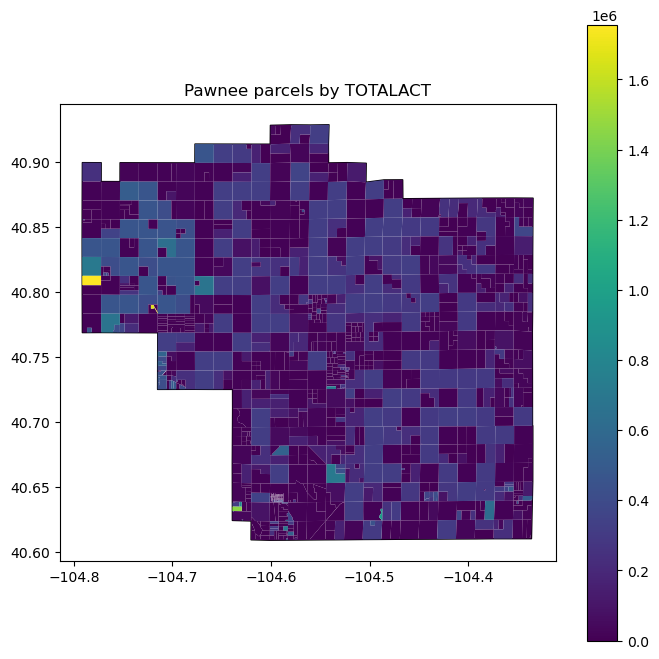

In [ ]:
# Simple TOTALACT map
# Do not constrain vmax yet
fig, ax = plt.subplots(figsize=(8, 8))
pawnee_union.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.8)
parcels.plot(ax=ax, column="TOTALACT", legend=True, linewidth=0.2)
format_land_value_map(ax, "Pawnee parcels by TOTALACT")
save_land_value_map(fig, "pawnee_parcels_totalact.png")
plt.show()

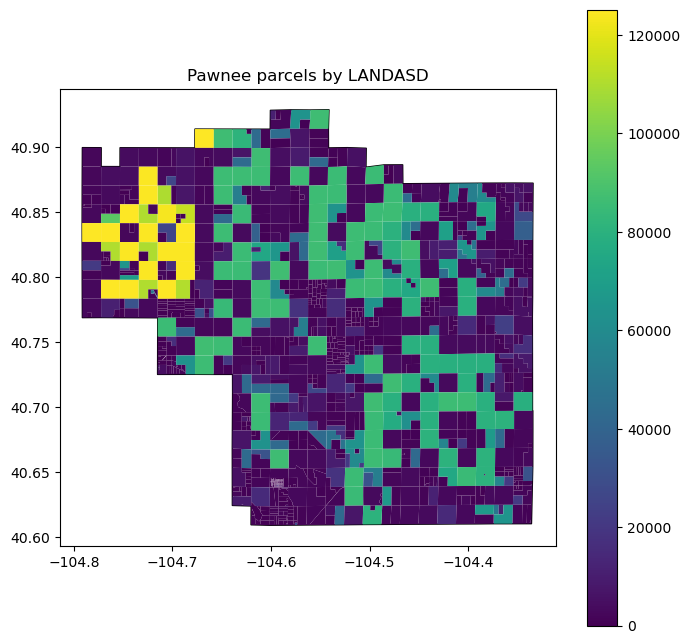

In [ ]:
# Simple LANDASD map
# Do not constrain vmax yet
fig, ax = plt.subplots(figsize=(8, 8))
pawnee_union.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.8)
parcels.plot(ax=ax, column="LANDASD", legend=True, linewidth=0.2)
format_land_value_map(ax, "Pawnee parcels by LANDASD")
save_land_value_map(fig, "pawnee_parcels_landasd.png")
plt.show()


In [20]:
# Inspect federal parcels separately, since we want Pawnee parcels held by "U S A" and 
# "COLORADO STATE OF"
if "NAME" in parcels.columns:
    owner_summary = (
        parcels.groupby("NAME", dropna=False)
        .agg(
            parcel_count=("PARCEL", "count"),
            total_market_value=("TOTALACT", "sum"),
            total_land_value=("LANDACT", "sum"),
            total_gis_acres=("GIS_Acres", "sum")
        )
        .sort_values("total_market_value", ascending=False)
    )
    display(owner_summary.head(20))


,parcel_count,total_market_value,total_land_value,total_gis_acres
NAME,,,,
U S A,246,53245226,50651965,113999.387565
COLORADO STATE OF,53,7595894,7595894,20463.770754
ATS ATLAS E HOLDINGS LLC,1,1676697,180432,25.134092
SIMPSON CLIFF E,1,1452307,8327,79.932451
CASS RANDOLPH J,2,1068258,2877,114.692842
,3,1054328,61473,53.400958
BALL TAMMIE L,6,1051087,81924,1765.472002
PAWNEE RIDGE RANCH LLC,2,990399,14231,655.664683
KCLINESTUD 5 LLC,1,821948,554,19.903924


# Mapping specifically variation of LANDASD/TOTALACT for USA and COLORADO STATE OF

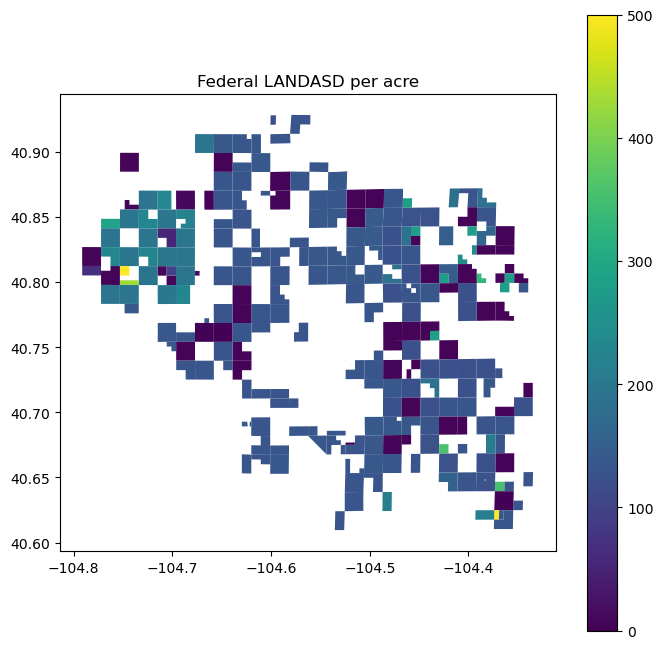

In [ ]:
# Federal mapping per acre (LANDASD)
# As size affects value greatly, the mapping here tries to contain extreme values.
# Here we calculate LANDASD per acre instead of per parcel.

usa = parcels[parcels["NAME"] == "U S A"].copy()
usa["landasd_per_acre"] = usa["LANDASD"] / usa["GIS_Acres"]

fig, ax = plt.subplots(figsize=(8, 8))

# Constrain vmax for better comparison
vmin = 0
vmax = 500

pawnee_union.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.8)
usa.plot(
    column="landasd_per_acre",
    cmap="viridis",
    legend=True,
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.2
)

format_land_value_map(ax, "Federal LANDASD per acre")
save_land_value_map(fig, "federal_landasd_per_acre.png")
plt.show()

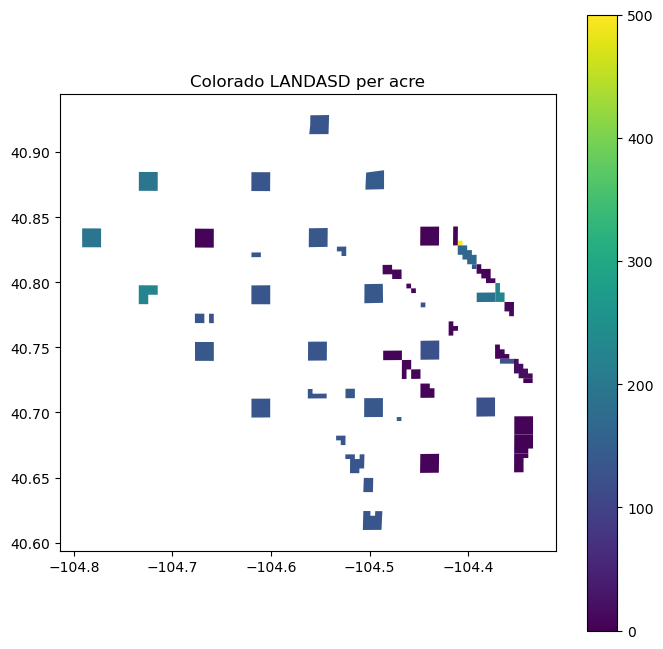

In [ ]:
# Colorado mapping per acre (LANDASD)
# As size affects value greatly, the mapping here tries to contain extreme values.
# Here we calculate LANDASD per acre instead of per parcel.

co = parcels[parcels["NAME"] == "COLORADO STATE OF"].copy()
co["landasd_per_acre"] = co["LANDASD"] / co["GIS_Acres"]

fig, ax = plt.subplots(figsize=(8, 8))

# Constrain vmax for better comparison
vmin = 0
vmax = 500

pawnee_union.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.8)
co.plot(
    column="landasd_per_acre",
    cmap="viridis",
    legend=True,
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.2
)

format_land_value_map(ax, "Colorado LANDASD per acre")
save_land_value_map(fig, "colorado_landasd_per_acre.png")
plt.show()


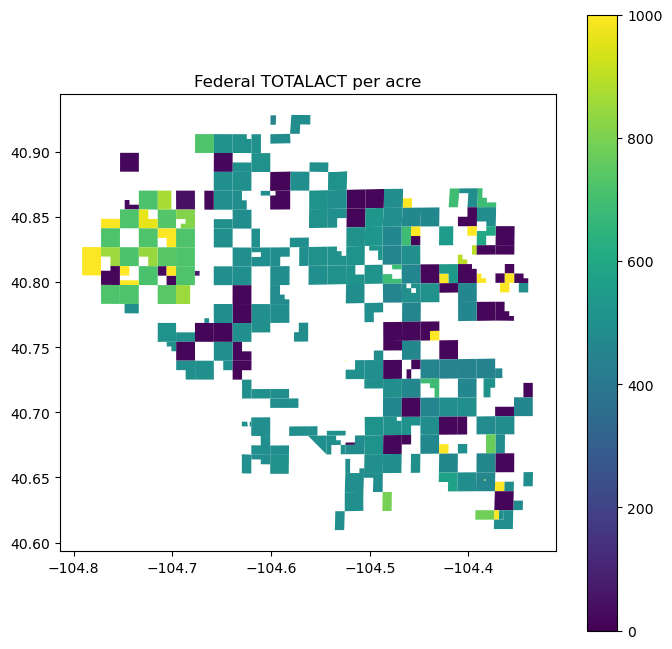

In [ ]:
# Federal mapping per acre (TOTALACT)
usa_act = parcels[parcels["NAME"] == "U S A"].copy()
usa_act["totalact_per_acre"] = usa_act["TOTALACT"] / usa_act["GIS_Acres"]

fig, ax = plt.subplots(figsize=(8, 8))

# Constrain vmax
vmin = 0
vmax = 1000

pawnee_union.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.8)
usa_act.plot(
    column="totalact_per_acre",
    cmap="viridis",
    legend=True,
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.2
)

format_land_value_map(ax, "Federal TOTALACT per acre")
save_land_value_map(fig, "federal_totalact_per_acre.png")
plt.show()

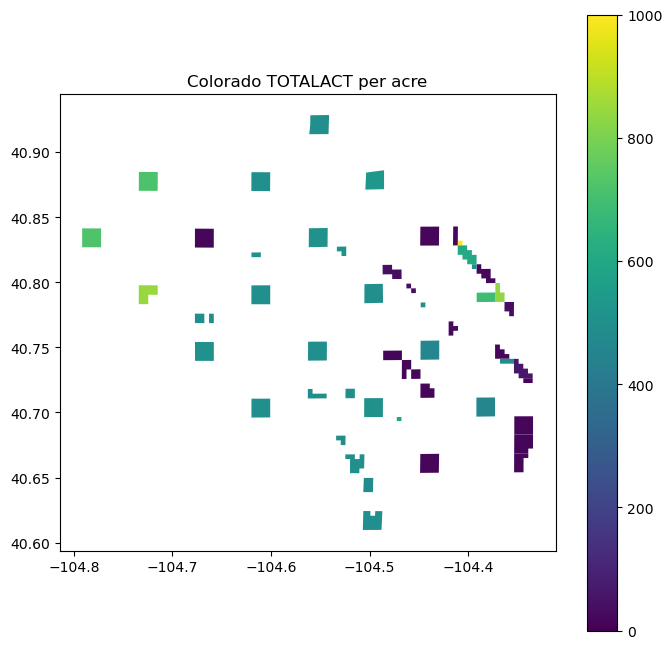

In [ ]:
# Colorado mapping per acre (TOTALACT)
co_act = parcels[parcels["NAME"] == "COLORADO STATE OF"].copy()
co_act["totalact_per_acre"] = co_act["TOTALACT"] / co_act["GIS_Acres"]

fig, ax = plt.subplots(figsize=(8, 8))

# Constrain vmax
vmin = 0
vmax = 1000

pawnee_union.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.8)
co_act.plot(
    column="totalact_per_acre",
    cmap="viridis",
    legend=True,
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.2
)

format_land_value_map(ax, "Colorado TOTALACT per acre")
save_land_value_map(fig, "colorado_totalact_per_acre.png")
plt.show()


# Export files for parcel matrix

In [ ]:
gpkg_path = parcel_dir / "pawnee_parcels_land_values.gpkg"
geojson_path = parcel_dir / "pawnee_parcels_land_values.geojson"
csv_path = parcel_dir / "pawnee_parcels_land_values.csv"
summary_path = parcel_dir / "pawnee_parcels_land_value_summary.csv"

parcels.to_file(gpkg_path, driver="GPKG")
parcels.to_file(geojson_path, driver="GeoJSON")

csv_fields = [c for c in [
    "PARCEL", "ACCOUNTNO", "NAME", "ACCTTYPE", "LEGAL", "TOTALACT", "LANDACT",
    "TOTALASD", "LANDASD", "GIS_Acres", "clip_acres_est",
    "value_per_gis_acre", "land_value_per_gis_acre", "value_per_clipped_acre",
    "TOWNSHIP", "RANGE", "SECTION", "STR2", "Latitude", "Longitude"
] if c in parcels.columns]

parcels[csv_fields].drop(columns="geometry", errors="ignore").to_csv(csv_path, index=False)
summary.to_csv(summary_path)

print("Saved:")
print(" -", gpkg_path)
print(" -", geojson_path)
print(" -", csv_path)
print(" -", summary_path)

Saved:
 - C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1\data\processed\land_values\pawnee_parcels_land_values.gpkg
 - C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1\data\processed\land_values\pawnee_parcels_land_values.geojson
 - C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1\data\processed\land_values\pawnee_parcels_land_values.csv
 - C:\Users\kayle\Desktop\earth-analytics\Pawnee-Grasslands-Project-1\data\processed\land_values\pawnee_parcels_land_value_summary.csv
